In [31]:
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cv2

In [32]:
input_dir_1 = "./data/black_larva/frames/"

input_dir_2 =  "./data/white_larva/frames/"

In [33]:
def show_masks_from_dirs(model, dir1, dir2, n=5):
    def load_images_from_dir(directory, n, reversed=False):
        files = [f for f in os.listdir(directory)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        files = sorted(files)[:n]
        paths = [os.path.join(directory, f) for f in files]

        images = []
        for p in paths:
            img = cv2.imread(p)
            if reversed:
                 img = img.max() - img
            images.append(img)

        return images, paths

    imgs1, paths1 = load_images_from_dir(dir1, n)
    imgs2, paths2 = load_images_from_dir(dir2, n, reversed=True)

    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

    for i in range(n):
        for j, (imgs, paths) in enumerate([(imgs1, paths1), (imgs2, paths2)]):

            ax = axes[i, j]
            img = imgs[i]
            path = paths[i]

            # Create a copy for overlay
            img_with_masks = img.copy().astype(float)

            # Run model
            #res = model(img, conf=0.5)
            res = model(img)
            if res[0].masks is not None:
                polygons = res[0].masks.xy
                h, w = img.shape[:2]

                for k, poly in enumerate(polygons):
                    if poly is None or len(poly) < 3:
                        print(k, "Invalid polygon, skipping")
                        continue

                    pts = np.array(poly, dtype=np.int32)

                    # Create a random color
                    color = (np.random.rand(3,) * 255).astype(int)

                    # Create a mask and fill it
                    mask = np.zeros((h, w, 3), dtype=np.uint8)
                    cv2.fillPoly(mask, [pts], (255, 255, 255))

                    # Blend mask with image
                    mask_bool = mask[:, :, 0] > 0
                    img_with_masks[mask_bool] = 0.6 * img_with_masks[mask_bool] + 0.4 * color

                    # Add ID text near the polygon
                    # Calculate centroid
                    #M = cv2.moments(pts)
                    #if M['m00'] != 0:
                    #    cx = int(M['m10'] / M['m00'])
                    #    cy = int(M['m01'] / M['m00'])
                    #    ax.text(cx-3, cy-3, f'{k}', color='white', fontsize=5, ha='center', va='center',
                    #            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5))

            ax.imshow(img_with_masks.astype(np.uint8))

            ax.set_title(os.path.basename(path), fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [34]:
model = YOLO("/Users/caglayantuna/larva_codes/my_codes/yolo_run_size_1048/segment/train/weights/best.pt")



0: 864x1056 33 larvas, 679.4ms
Speed: 25.8ms preprocess, 679.4ms inference, 209.8ms postprocess per image at shape (1, 3, 864, 1056)

0: 704x1056 68 larvas, 753.7ms
Speed: 7.4ms preprocess, 753.7ms inference, 338.5ms postprocess per image at shape (1, 3, 704, 1056)

0: 864x1056 33 larvas, 471.1ms
Speed: 10.0ms preprocess, 471.1ms inference, 148.1ms postprocess per image at shape (1, 3, 864, 1056)

0: 704x1056 73 larvas, 381.3ms
Speed: 7.7ms preprocess, 381.3ms inference, 356.9ms postprocess per image at shape (1, 3, 704, 1056)

0: 864x1056 33 larvas, 447.8ms
Speed: 9.6ms preprocess, 447.8ms inference, 168.4ms postprocess per image at shape (1, 3, 864, 1056)

0: 704x1056 76 larvas, 485.2ms
Speed: 42.7ms preprocess, 485.2ms inference, 317.2ms postprocess per image at shape (1, 3, 704, 1056)

0: 864x1056 32 larvas, 1331.0ms
Speed: 31.1ms preprocess, 1331.0ms inference, 378.0ms postprocess per image at shape (1, 3, 864, 1056)

0: 704x1056 76 larvas, 474.6ms
Speed: 34.5ms preprocess, 474.6

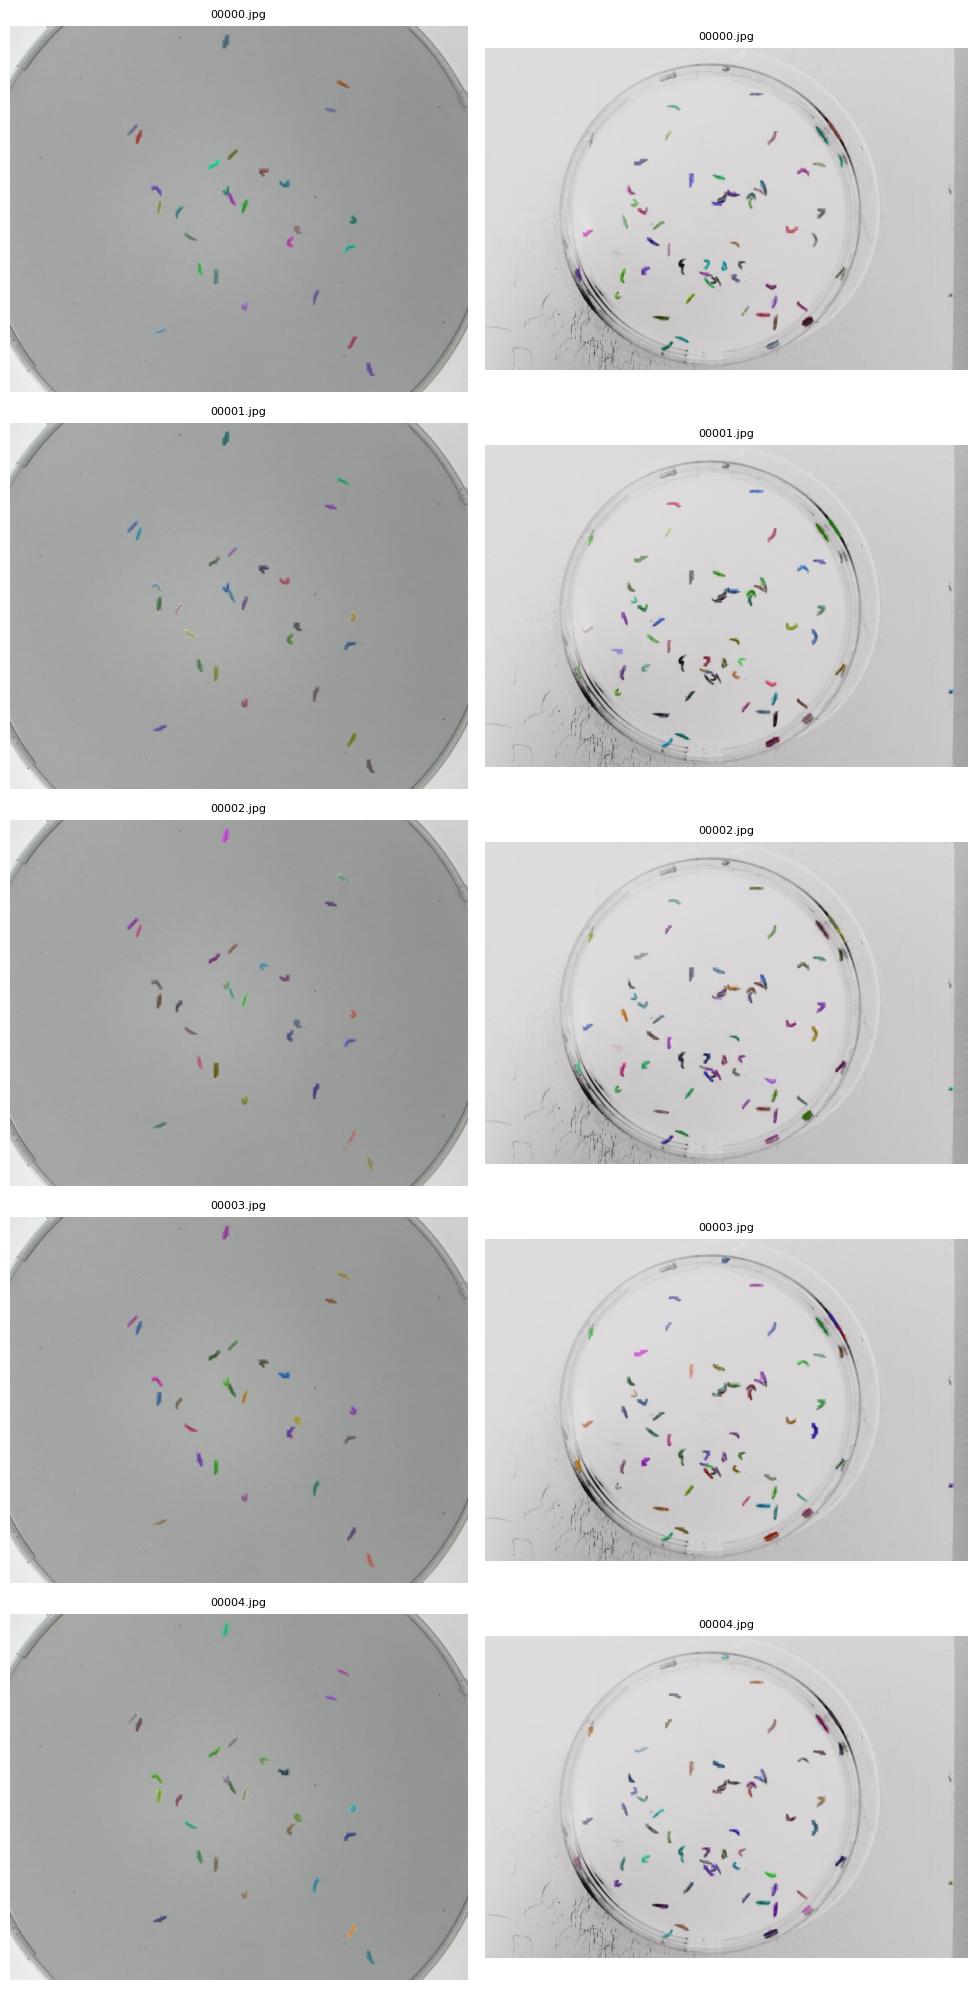

In [35]:
show_masks_from_dirs(model, input_dir_1, input_dir_2, n=5)


0: 864x1056 33 larvas, 1693.9ms
Speed: 17.4ms preprocess, 1693.9ms inference, 922.3ms postprocess per image at shape (1, 3, 864, 1056)

0: 1056x1056 48 larvas, 901.4ms
Speed: 31.0ms preprocess, 901.4ms inference, 669.3ms postprocess per image at shape (1, 3, 1056, 1056)

0: 864x1056 33 larvas, 1347.1ms
Speed: 19.7ms preprocess, 1347.1ms inference, 189.3ms postprocess per image at shape (1, 3, 864, 1056)

0: 1056x1056 52 larvas, 2935.8ms
Speed: 15.3ms preprocess, 2935.8ms inference, 1113.0ms postprocess per image at shape (1, 3, 1056, 1056)

0: 864x1056 33 larvas, 419.6ms
Speed: 9.9ms preprocess, 419.6ms inference, 133.5ms postprocess per image at shape (1, 3, 864, 1056)

0: 1056x1056 46 larvas, 517.3ms
Speed: 12.2ms preprocess, 517.3ms inference, 309.8ms postprocess per image at shape (1, 3, 1056, 1056)

0: 864x1056 32 larvas, 423.4ms
Speed: 8.4ms preprocess, 423.4ms inference, 134.2ms postprocess per image at shape (1, 3, 864, 1056)

0: 1056x1056 50 larvas, 783.1ms
Speed: 24.9ms prep

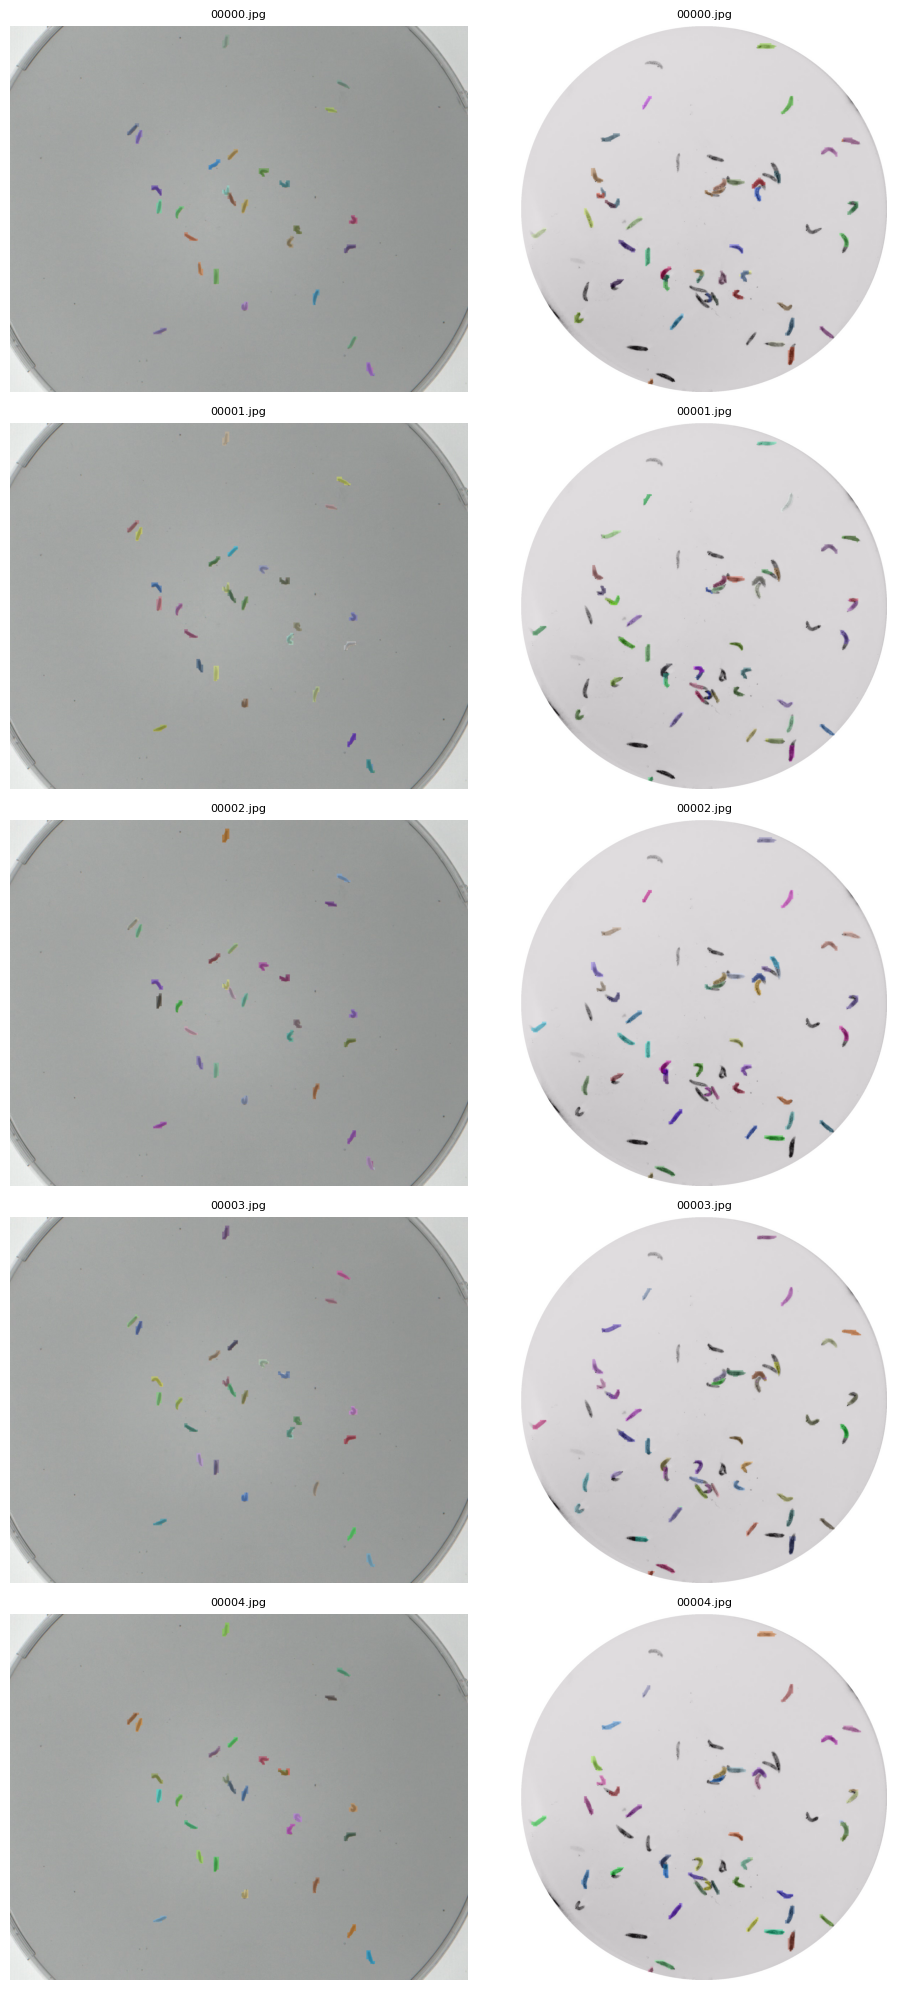

In [36]:
input_dir_3 = "./data/white_larva/frames_cropped/"
show_masks_from_dirs(model, input_dir_1, input_dir_3, n=5)